In [1]:
library(tidyverse)
library(readxl)
library(dplyr)
#library(evola3)
library(evola.exp)
library(forecast)
library(lmtest)
library(lubridate)
library(corrplot)
library(MASS)
#setwd(dirname(rstudioapi::getSourceEditorContext()$path))
def_user("evazquez", servidor = 165)



── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Cargando paquete requerido: zoo


Adjuntando el paquete: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric


corrplot 0.95 loaded


Adjuntando el paquete: 'MASS'


The following object is masked from 'package:dplyr':

    select




# Modelo Regresión Lineal O3

#### con datos de ONI desde 2012

In [4]:
# establecer fechas

year1 <- 2012
year2 <- as.numeric(format(Sys.Date(), "%Y")) -1
meses <- c(
  "enero", "febrero", "marzo", "abril", "mayo", "junio",
  "julio", "agosto", "septiembre", "octubre", "noviembre", "diciembre"
)


oni_meses <- c(
  "DJF" = "enero",
  "JFM" = "febrero",
  "FMA" = "marzo",
  "MAM" = "abril",
  "AMJ" = "mayo",
  "MJJ" = "junio",
  "JJA" = "julio",
  "JAS" = "agosto",
  "ASO" = "septiembre",
  "SON" = "octubre",
  "OND" = "noviembre",
  "NDJ" = "diciembre"
)

In [6]:
# Cargar bases

url_mei <- "https://psl.noaa.gov/enso/mei/data/meiv2.data"
nombres_bimestrales <- c(
  "DJ", "JF", "FM", "MA", "AM", "MJ", "JJ", "JA", "AS", "SO", "ON", "ND")
nombres_trimestrales <- c("DJF", "JFM", "FMA", "MAM", "AMJ", "MJJ", 
                          "JJA", "JAS", "ASO", "SON", "OND", "NDJ")



oni <- read.table(
  "https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt",
  header = TRUE
) %>% 
  rename(Year = YR, meses = SEAS , oni = ANOM) %>% 
  filter(Year >= year1, Year < year(Sys.Date())) %>% 
  dplyr::select(- TOTAL) %>% 
  dplyr::mutate(oni = round(oni, 1),
         month = oni_meses[meses],
         month = factor(month, levels = .env$meses))


## Observados de ozono
o3.d <- evola.exp::redes_con(start = year1, end = year2) %>% 
  evola.exp::filtrar_est(transporte = F) %>% 
  dplyr::group_by(date = as.Date(date)) %>% 
  dplyr::summarise(valor = max(valor, na.rm = T))

In [7]:
## Conteo de dias >= 155 por año
o3.m <- o3.d %>%
  group_by(Year = format(date, "%Y"), month = format(date, "%B")) %>%
  summarise(ndias = sum(valor >= 155, na.rm = T)) %>% 
  arrange(Year)
  # %>% filter(Year != 2024)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Year and month.
ℹ Output is grouped by Year.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Year, month))` for per-operation grouping (`?dplyr::dplyr_by`) instead.


In [9]:
# datos para modelos de regresión
oni.conts <- o3.m %>%
  mutate(
    Year = as.numeric(Year),
    month = factor(month, levels = .env$meses)
  ) %>%
  left_join(
    oni %>% dplyr::select(Year, month, oni),
    by = c("Year", "month")
  )

In [10]:
## Modelo de regresion lineal

conts.lm <- lm(ndias ~ Year + month + oni, data = oni.conts)

conts.lm 


Call:
lm(formula = ndias ~ Year + month + oni, data = oni.conts)

Coefficients:
    (Intercept)             Year     monthfebrero       monthmarzo  
      24.927510        -0.012361         0.568959         1.139152  
     monthabril        monthmayo       monthjunio       monthjulio  
       1.713051         3.140387         0.355908         0.216756  
    monthagosto  monthseptiembre     monthoctubre   monthnoviembre  
       0.078839         0.008645         0.146562         0.358378  
 monthdiciembre              oni  
      -0.004940         0.172899  


In [11]:
# Serie de tiempo
oni.ts <- ts(oni.conts$oni, start = c(year1, 1), end = c(year2, 12), frequency = 12)
oni.ts.mod <- auto.arima(oni.ts, seasonal = T)
oni.pron <- forecast(oni.ts.mod, h = 6)


In [13]:
## Datos para predicción de modelo de regresion lineal
new.data <- data.frame(Year = year2+1,
                       month = factor(c("febrero", "marzo", "abril", "mayo", "junio"), levels = meses),
                       oni = round(oni.pron$mean[-1], 1)) 



## Prediccion y ajuste de nuevos datos
preds <- predict(conts.lm, newdata = new.data, interval = "confidence")
preds <- cbind(new.data, ceiling(preds)) %>% dplyr::select("month", "lwr", "fit", "upr") %>% mutate(month = as.character(month))
preds <- rbind(preds, c("Total", colSums(preds[-1])))

cat("\n============================\n")
cat("===== PREDICCIÓN DEL MODELO =====\n")
cat("\n============================\n")

preds


===== PREDICCIÓN DEL MODELO =====



,month,lwr,fit,upr
,<chr>,<chr>,<chr>,<chr>
1,febrero,0,1,2
2,marzo,1,2,2
3,abril,1,2,3
4,mayo,3,3,4
5,junio,0,1,2
6,Total,5,9,13


# Evaluación del modelo

# Regresión Lineal con TMP y WSP

In [20]:
# Carga de datos

year1 <- 2012
year2 <- as.numeric(format(Sys.Date(), "%Y")) #- 1
meses <- c("enero", "febrero", "marzo", "abril", "mayo", "junio", "julio", "agosto", "septiembre", "octubre", "noviembre", "diciembre")

# Carga de datos viento y temperatura 

temperatura <- evola.exp::redes_con(
  red = "redmet",
  parametros = "tmp",
  start = year1,
  end = year2
)




v_viento <- evola.exp::redes_con(
  red = "redmet",
  parametros = "wsp",
  start = year1,
  end = year2
)
# Promedio de viento

wsp.d <- v_viento %>%
  mutate(date = as.Date(date),
         Year = lubridate::year(date),
         mes = lubridate::month(date)) %>%
  group_by(Year, mes) %>%
  summarise(
    wsp = mean(valor, na.rm = T),
    wsp_max = max(valor, na.rm = T),
    .groups = "drop"
  ) %>% 
  dplyr::filter(Year != year2) %>% 
  mutate(month = month(mes, label = T, abbr = F))


# Variable de viento bajo

wsp_bajo <- v_viento %>%
  mutate(date = as.Date(date)) %>%
  group_by(date) %>%
  summarise(
    wsp_dia = mean(valor, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    Year = as.numeric(format(date, "%Y")),
    month = format(date, "%B")
  ) %>%
  group_by(Year, month) %>%
  summarise(
    ndias_wsp_bajo = sum(wsp_dia <= 1.5, na.rm = TRUE),
    wsp = mean(wsp_dia, na.rm = TRUE),
    .groups = "drop"
  )



# Media, maximo de temperaturas y conteo de dias de temperaturas

tmp.d <- temperatura %>%
  mutate(date = as.Date(date)) %>%
  
  # máximo diario
  group_by(date) %>%
  summarise(
    tmp_prom = mean(valor, na.rm = TRUE),
    tmp_max = max(valor, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  
  # agregación mensual
  group_by(
    Year = format(date, "%Y"),
    month = format(date, "%B")
  ) %>%
  
  summarise(
    
    ndias_28 = sum(tmp_max >= 28, na.rm = TRUE),
    ndias_29 = sum(tmp_max >= 29, na.rm = TRUE),
    ndias_30 = sum(tmp_max >= 30, na.rm = TRUE),
    ndias_31 = sum(tmp_max >= 31, na.rm = TRUE),
    ndias_32 = sum(tmp_max >= 32, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  
  filter(Year != year2)

In [17]:
# Cargar datos ONI

oni <- read.csv("\\\\192.168.17.149\\Analisis\\ENSO\\Tablas\\enso.csv")



oni <- round(oni, 1) %>% 
  filter(YR >= 1990)

colnames(oni) <- c("Year", meses)
oni <- gather(oni, month, oni, -Year) %>% 
  dplyr::filter(Year >= year1) %>% 
  dplyr::arrange(Year)

In [21]:
# Datos horarios O3
o3.d <- evola.exp::redes_con(start = year1, end = year2) %>% 
  evola.exp::filtrar_est(transporte = F) %>% 
  dplyr::group_by(date = as.Date(date)) %>% 
  dplyr::summarise(valor = max(valor, na.rm = T))

In [22]:
## Conteo de dias >= 155 por año
o3.m <- o3.d %>%
  dplyr::group_by(Year = format(date, "%Y"), month = format(date, "%B")) %>%
  dplyr::summarise(ndias = sum(valor >= 155, na.rm = T)) %>% 
  dplyr::filter(Year != year2)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Year and month.
ℹ Output is grouped by Year.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Year, month))` for per-operation grouping (`?dplyr::dplyr_by`) instead.


In [29]:
## Datos para modelo de regresion

# Se agrega o3 con oni

oni.conts <- merge(oni, o3.m, sort = F) %>% 
  dplyr::mutate(month = factor(month, levels = meses))


# se agregan datos de tmp

oni.conts <- merge(oni.conts, tmp.d, sort = F) %>% 
  dplyr::mutate(month = factor(month, levels = meses))


# oni.conts <- merge(oni.conts, wsp.d, sort = F) %>% 
#   dplyr::mutate(month = factor(month, levels = meses))



# ONI por categorias

oni.conts <- oni.conts %>%
  mutate(
    oni_cat = case_when(
      oni >= 0.5 ~ "Nino",
      oni <= -0.5 ~ "Nina",
      TRUE ~ "Neutral"
    ),
    oni_cat = factor(oni_cat, levels = c("Nina", "Neutral", "Nino"))
  )


# Filtrar solo temporada de ozono
oni.temp <- oni.conts %>%
  filter(month %in% c("febrero","marzo","abril","mayo", "junio"))

# Agregar viento bajo

oni.temp <- oni.temp %>%
  left_join(wsp_bajo, by = c("Year", "month"))



# Modelo con wsp centrado

oni.temp <- oni.temp %>%
  mutate(
    wsp_c = wsp - mean(wsp, na.rm = TRUE)
  )


# Comparacion  de modelos con temperaturas

mod_28 <- lm(ndias ~ Year + month + ndias_28 + wsp, data = oni.temp)
mod_29 <- lm(ndias ~ Year + month + ndias_29 + wsp, data = oni.temp)
mod_30 <- lm(ndias ~ Year + month + ndias_30 + wsp, data = oni.temp)
mod_31 <- lm(ndias ~ Year + month + ndias_31 + wsp, data = oni.temp) # mejor modelo
mod_32 <- lm(ndias ~ Year + month + ndias_32 + wsp, data = oni.temp)

comparacion <- data.frame(
  modelo = c("ndias_28", "ndias_29", "ndias_30", "ndias_31", "ndias_32"),
  RSE = c(summary(mod_28)$sigma,
          summary(mod_29)$sigma,
          summary(mod_30)$sigma,
          summary(mod_31)$sigma,
          summary(mod_32)$sigma),
  R2_ajustado = c(summary(mod_28)$adj.r.squared,
                  summary(mod_29)$adj.r.squared,
                  summary(mod_30)$adj.r.squared,
                  summary(mod_31)$adj.r.squared,
                  summary(mod_32)$adj.r.squared),
  AIC = c(AIC(mod_28),
          AIC(mod_29),
          AIC(mod_30),
          AIC(mod_31),
          AIC(mod_32)),
  BIC = c(BIC(mod_28),
          BIC(mod_29),
          BIC(mod_30),
          BIC(mod_31),
          BIC(mod_32))
)

comparacion



modelo,RSE,R2_ajustado,AIC,BIC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ndias_28,2.032493,0.1822930,307.4530,327.6894
ndias_29,1.999812,0.2083782,305.1836,325.4200
ndias_30,1.975505,0.2275051,303.4715,323.7079
ndias_31,1.948395,0.2485614,301.5370,321.7734
ndias_32,1.978616,0.2250700,303.6918,323.9282


In [30]:
# Modelo con interaccion
mod_inter_c <- lm(
  ndias ~ Year + month + ndias_31 * wsp_c,
  data = oni.temp
)

summary(mod_inter_c)
AIC(mod_31, mod_inter_c)
BIC(mod_31, mod_inter_c)


Call:
lm(formula = ndias ~ Year + month + ndias_31 * wsp_c, data = oni.temp)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.4309 -1.0870 -0.1932  0.9879  5.9805 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)    227.06782  120.40100   1.886 0.064068 .  
Year            -0.11202    0.05972  -1.876 0.065469 .  
monthfebrero    -0.46843    0.79950  -0.586 0.560104    
monthjunio      -1.02566    0.72603  -1.413 0.162830    
monthmarzo      -0.26186    0.71975  -0.364 0.717245    
monthmayo        0.60175    0.72396   0.831 0.409103    
ndias_31         0.18901    0.04788   3.947 0.000207 ***
wsp_c            0.58074    1.89782   0.306 0.760645    
ndias_31:wsp_c  -0.84268    0.27737  -3.038 0.003502 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 1.831 on 61 degrees of freedom
Multiple R-squared:  0.4135,	Adjusted R-squared:  0.3366 
F-statistic: 5.377 on 8 and 61 DF,  p-value: 3.96e-05


,df,AIC
,<dbl>,<dbl>
mod_31,9,301.5370
mod_inter_c,10,293.6738


,df,BIC
,<dbl>,<dbl>
mod_31,9,321.7734
mod_inter_c,10,316.1587


In [31]:
# Probar GLM con poisoon


mod_pois <- glm(
  ndias ~ Year + month + ndias_31 * wsp_c,
  data = oni.temp,
  family = poisson()
)

summary(mod_pois)


Call:
glm(formula = ndias ~ Year + month + ndias_31 * wsp_c, family = poisson(), 
    data = oni.temp)

Coefficients:
                Estimate Std. Error z value Pr(>|z|)    
(Intercept)    172.24757   59.90060   2.876 0.004033 ** 
Year            -0.08524    0.02973  -2.868 0.004136 ** 
monthfebrero    -0.80403    0.45612  -1.763 0.077944 .  
monthjunio      -1.44605    0.50488  -2.864 0.004181 ** 
monthmarzo      -0.26003    0.33570  -0.775 0.438594    
monthmayo        0.20353    0.28849   0.705 0.480509    
ndias_31         0.06460    0.01889   3.421 0.000624 ***
wsp_c            0.32566    1.24810   0.261 0.794148    
ndias_31:wsp_c  -0.24903    0.12875  -1.934 0.053100 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 188.84  on 69  degrees of freedom
Residual deviance: 113.47  on 61  degrees of freedom
AIC: 227.67

Number of Fisher Scoring iterations: 6


In [33]:
# Prueba binomial negativa



mod_nb <- glm.nb(
  ndias ~ Year + month + ndias_31 * wsp_c,
  data = oni.temp
)

summary(mod_nb)

# Comparación de modelo con poisson

AIC(mod_pois, mod_nb)


Call:
glm.nb(formula = ndias ~ Year + month + ndias_31 * wsp_c, data = oni.temp, 
    init.theta = 1.799674101, link = log)

Coefficients:
                Estimate Std. Error z value Pr(>|z|)  
(Intercept)    118.28053   81.62156   1.449   0.1473  
Year            -0.05848    0.04049  -1.444   0.1487  
monthfebrero    -0.81804    0.57013  -1.435   0.1513  
monthjunio      -1.42451    0.58559  -2.433   0.0150 *
monthmarzo      -0.23198    0.44924  -0.516   0.6056  
monthmayo        0.16444    0.42194   0.390   0.6967  
ndias_31         0.05843    0.02886   2.025   0.0429 *
wsp_c            0.08784    1.53385   0.057   0.9543  
ndias_31:wsp_c  -0.22376    0.18400  -1.216   0.2240  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(1.7997) family taken to be 1)

    Null deviance: 108.193  on 69  degrees of freedom
Residual deviance:  72.962  on 61  degrees of freedom
AIC: 220.11

Number of Fisher Scoring iterations: 1


     

,df,AIC
,<dbl>,<dbl>
mod_pois,9,227.6718
mod_nb,10,220.1122


In [36]:
# Validación con datos temporales

train <- oni.temp %>%
  filter(Year <= 2018)

test <- oni.temp %>%
  filter(Year >= 2019)

wsp_mean_train <- mean(train$wsp, na.rm = TRUE)

train <- train %>%
  mutate(wsp_c = wsp - wsp_mean_train)

test <- test %>%
  mutate(wsp_c = wsp - wsp_mean_train)



In [37]:
# Validacion temporal con regresion lineal binomial

mod_nb_train <- MASS::glm.nb(
  ndias ~ Year + month + ndias_31 + wsp_c,
  data = train
)

pred_nb <- predict(
  mod_nb_train,
  newdata = test,
  type = "response"
)

error <- test$ndias - pred_nb

data.frame(
  ME = mean(error, na.rm = TRUE),
  RMSE = sqrt(mean(error^2, na.rm = TRUE)),
  MAE = mean(abs(error), na.rm = TRUE)
)

ME,RMSE,MAE
<dbl>,<dbl>,<dbl>
-1.866672,4.563819,2.370194


In [35]:
# Validacion temporal con regresion lineal normal
mod_train <- lm(
  ndias ~ Year + month + ndias_31 * wsp_c,
  data = train
)

pred <- predict(mod_train, newdata = test)

error <- test$ndias - pred

data.frame(
  ME = mean(error, na.rm = TRUE),
  RMSE = sqrt(mean(error^2, na.rm = TRUE)),
  MAE = mean(abs(error), na.rm = TRUE)
)

ME,RMSE,MAE
<dbl>,<dbl>,<dbl>
-1.265164,2.481538,1.826796


In [ ]:
## Regresión lineal normal con interacción de ndias_31 * wspc 
## ** mejor modelo 

## Modelo con oni categorico

In [9]:
## Modelo de regresion lineal


conts.lm <- lm(ndias~., oni.conts)

# ONI con CAT (continuo)
conts.lm <- lm(ndias ~ Year + month + oni_cat + ndias_30, data = oni.conts)


In [10]:
# Resunen de modelo 

summary(conts.lm)


Call:
lm(formula = ndias ~ Year + month + oni_cat + ndias_30, data = oni.conts)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.0797 -0.4675 -0.0732  0.3307  6.6870 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     147.81519   61.88291   2.389 0.018138 *  
Year             -0.07316    0.03063  -2.389 0.018130 *  
monthfebrero      0.38348    0.49230   0.779 0.437219    
monthmarzo        0.32273    0.53274   0.606 0.545550    
monthabril        0.69104    0.57998   1.191 0.235322    
monthmayo         1.95112    0.59244   3.293 0.001232 ** 
monthjunio       -0.11626    0.51140  -0.227 0.820458    
monthjulio        0.15269    0.49063   0.311 0.756062    
monthagosto      -0.02380    0.49084  -0.048 0.961383    
monthseptiembre  -0.08810    0.49078  -0.180 0.857774    
monthoctubre      0.05022    0.49076   0.102 0.918627    
monthnoviembre    0.30017    0.49061   0.612 0.541566    
monthdiciembre    0.02593    0.49046   0.053 0.957904   

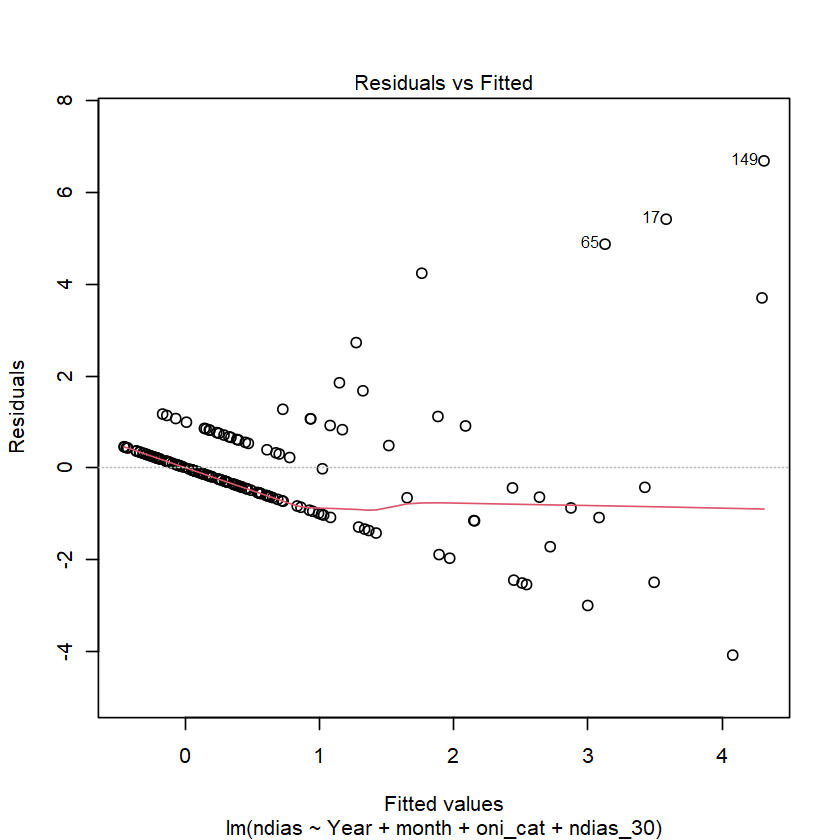

In [11]:
# Linealidad
# Observaciones: hay curvatura no linealidad
# el modelo no esta capturando bien la información

plot(conts.lm, which = 1)

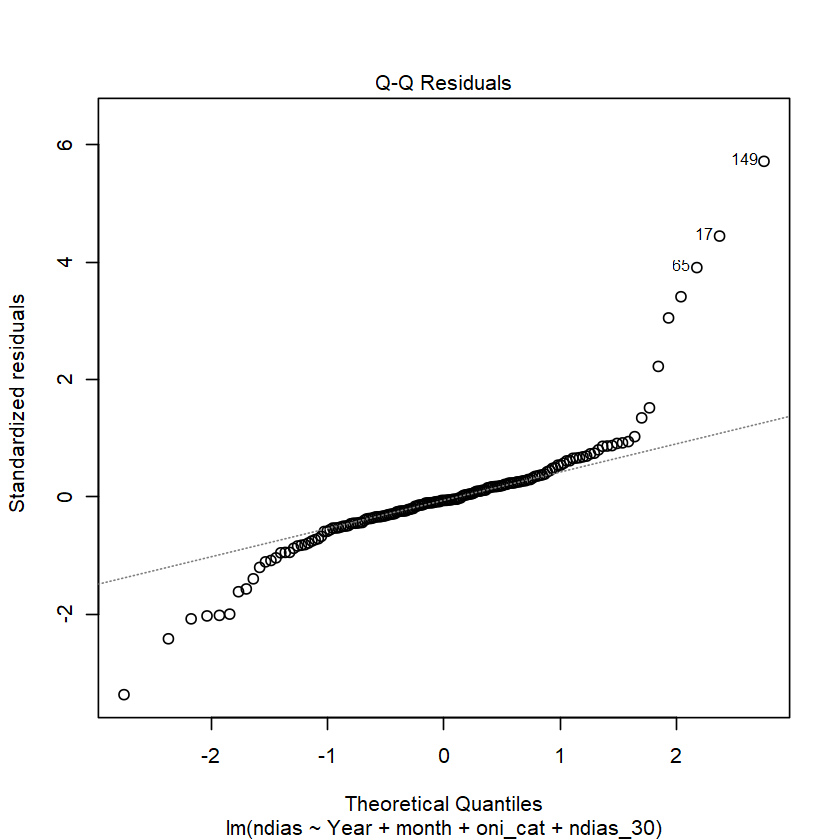

In [12]:
# Normalidad
# Observacionesd: No normalidad, las colas se despegan
plot(conts.lm, which = 2)

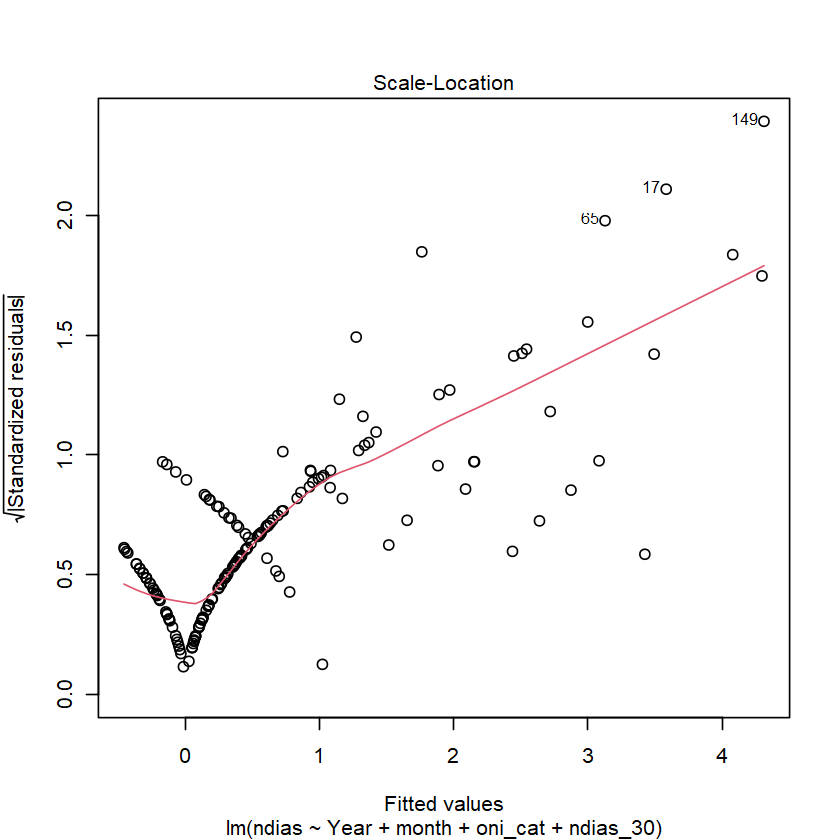

In [13]:
# Homocedasticidad
# Observaciones: la linea roja sube
# dispersion aumenta con fitted values

plot(conts.lm, which = 3)

In [16]:
# Test

bptest(conts.lm)


	studentized Breusch-Pagan test

data:  conts.lm
BP = 84.572, df = 15, p-value = 1.009e-11


In [17]:
# Independencia (DW)

dwtest(conts.lm)


	Durbin-Watson test

data:  conts.lm
DW = 1.8417, p-value = 0.1266
alternative hypothesis: true autocorrelation is greater than 0


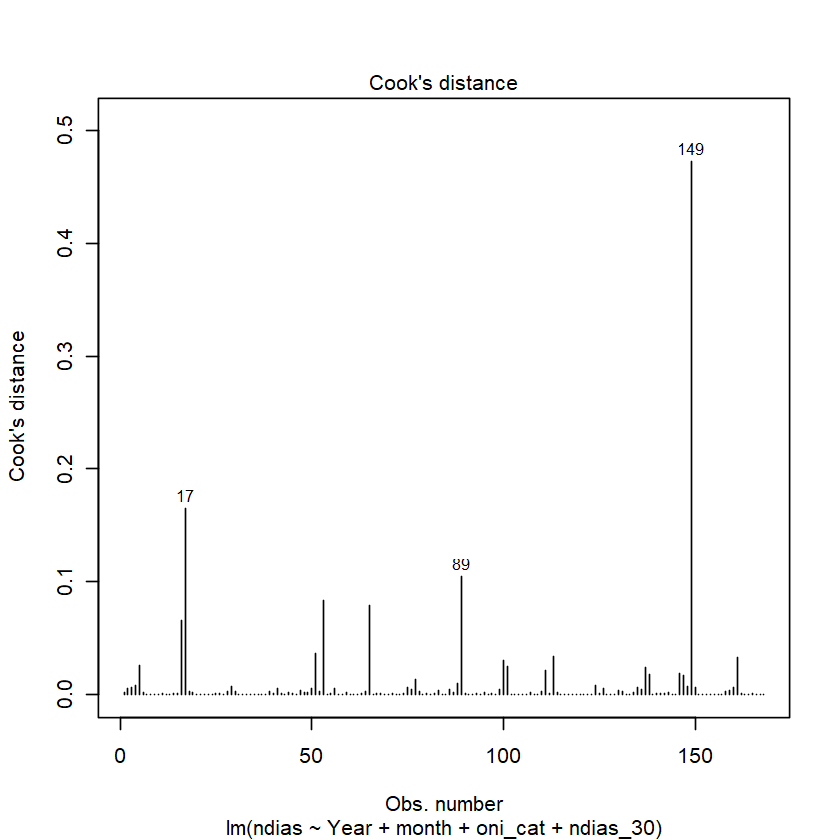

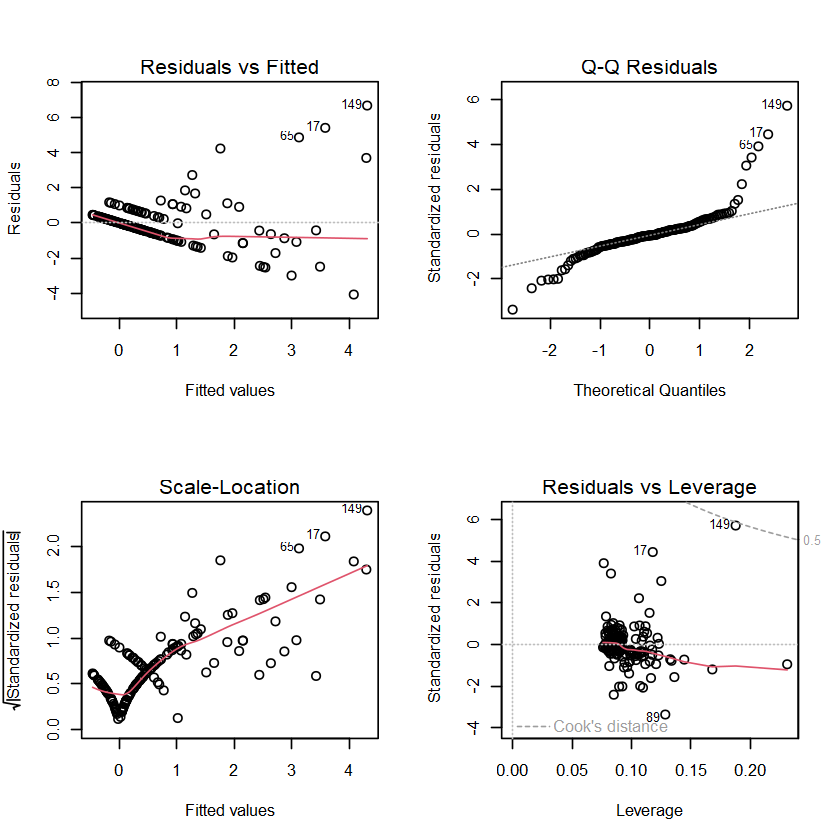

In [19]:
#Outliers
# Observaciones: algunos puntos con leverage moderado

plot(conts.lm, which = 4)

# todo en uno
par(mfrow = c(2,2))
plot(conts.lm)

In [21]:
oni.ts <- ts(oni.conts$oni, start = c(year1, 1), end = c(year2, 12), frequency = 12)
oni.ts.mod <- auto.arima(oni.ts, seasonal = T)
oni.pron <- forecast(oni.ts.mod, h = 6)

## Datos para predicción de modelo de regresion lineal
new.data <- data.frame(Year = year2+1,
                       month = factor(c("febrero", "marzo", "abril", "mayo", "junio"), levels = meses),
                       oni = round(oni.pron$mean[-1], 1)) 


# Datos para prediccion con ONI categorico


new.data <- data.frame(
  Year = year2 + 1,
  month = factor(c("febrero", "marzo", "abril", "mayo", "junio"), levels = meses),
  oni = round(oni.pron$mean[-1], 1)
) %>%
  mutate(
    oni_cat = case_when(
      oni >= 0.5 ~ "Niño",
      oni <= -0.5 ~ "Niña",
      TRUE ~ "Neutral"
    ),
    oni_cat = factor(oni_cat, levels = levels(oni.conts$oni_cat)),
    ndias_30 = c(3, 8, 12, 18, 10) # CHECAR ESTO
  )


names(new.data)

## Prediccion y ajuste de nuevos datos
preds <- predict(conts.lm, newdata = new.data, interval = "confidence")
preds <- cbind(new.data, ceiling(preds)) %>% select("month", "lwr", "fit", "upr") %>% mutate(month = as.character(month))
preds <- rbind(preds, c("Total", colSums(preds[-1])))

names(preds) <- c("mes", "Minimo", "Promedio", "Maximo")

preds

[1] "Year"     "month"    "oni"      "oni_cat"  "ndias_30"

,mes,Minimo,Promedio,Maximo
,<chr>,<chr>,<chr>,<chr>
1,febrero,-1,0,1
2,marzo,0,1,2
3,abril,1,1,2
4,mayo,2,3,4
5,junio,0,0,1
6,Total,2,5,10
